# Experimental Evaluation

In [1]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

font = {
        'size'   : 11}
mpl.rc('font', **font)

## Helper functions

In [2]:
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

In [3]:
def set_size(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)


In [4]:
def set_square_size(width_pt, fraction=1):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    return (fig_width_in, fig_width_in)

In [5]:
def csv_info(table, verdict_str, time_str):
    print("Number of instances:", table.shape[0])
    print("SAT:", table.query(verdict_str + " == 'sat'").shape[0])
    print("UNSAT:", table.query(verdict_str + " == 'unsat'").shape[0])
    print("SAT or UNSAT:", table.query(verdict_str + " == 'sat' or " + verdict_str + " == 'unsat'").shape[0])
    print("UNKNOWN:", table.query(verdict_str + " == 'unknown'").shape[0])
    print("TIMEOUT:", table.query(verdict_str + " == 'timeout'").shape[0])
    count_errors = table[table[verdict_str].str.contains("error:", na=False)].shape[0]
    print("ERROR:", count_errors)

In [6]:
def plot_survival(table, solvers, verdict_types, labels, colors, y_text, plot_name):
    solver_times_sorted = {}
    solver_cumulative_sol = {}
    solver_plot = {}
    
    plt.figure(figsize=(8,6))
    
    for solver in solvers:
        verdict_col = f'verdict_{solver}'
        time_col = f'time_{solver}'
        
        times = table.loc[table[verdict_col].isin(verdict_types), time_col]
        times = pd.to_numeric(times, errors='coerce').dropna()
    
        solver_times_sorted[solver] = np.sort(times)
        solver_cumulative_sol[solver] = np.arange(1, len(solver_times_sorted[solver])+1)
    
        solver_plot[solver] = np.clip(solver_times_sorted[solver], min_time, None)
        solver_plot[solver] = np.append(solver_plot[solver], max_time)
        solver_cumulative_sol[solver] = np.append(solver_cumulative_sol[solver], solver_cumulative_sol[solver][-1])
    
        plt.step(solver_plot[solver], solver_cumulative_sol[solver], where='post', color = colors[solver], label=labels[solver])
    
    plt.xlabel('Time (seconds)')
    plt.ylabel(y_text)
    plt.legend()
    plt.grid(True, which='both')
    
    plt.xscale('log', base=10)
    ax = plt.gca()
    ax.set_xlim(min_time, max_time)
    plt.xticks([min_time*(10**i) for i in range(int(np.log10(max_time))+2)])
    
    plt.savefig(plot_name, format="pgf", bbox_inches="tight")
    plt.show()

In [7]:
def plot_scatter_solvers(table, solvers, verdict_types, labels, colors, plot_name, min_time=None, max_time=None, category_col=None, category_colors=None, category_labels=None, logscale=True):
    """
    Create a scatter plot comparing the runtime of two solvers.
    
    Parameters:
    - table: DataFrame with solver results
    - solvers: list of exactly 2 solver names
    - verdict_types: list of verdict types to include
    - labels: dict mapping solver names to display labels
    - colors: dict mapping solver names to colors (not used if category_col is provided)
    - plot_name: filename for the output pgf file
    - min_time: minimum time for axis (optional)
    - max_time: maximum time for axis (optional)
    - category_col: column name containing categories (optional)
    - category_colors: dict mapping category values to colors (required if category_col is provided)
    - category_labels: dict mapping category values to display labels (required if category_col is provided)
    - logscale: boolean to use logarithmic scale (default: True)
    """
    
    # Ensure we have exactly 2 solvers
    if len(solvers) != 2:
        raise ValueError("This function expects exactly 2 solvers")
    
    solver1, solver2 = solvers[0], solvers[1]
    verdict_col1 = f'verdict_{solver1}'
    time_col1 = f'time_{solver1}'
    verdict_col2 = f'verdict_{solver2}'
    time_col2 = f'time_{solver2}'
    
    # Filter for instances solved by both solvers with the specified verdicts
    mask1 = table[verdict_col1].isin(verdict_types)
    mask2 = table[verdict_col2].isin(verdict_types)
    mask = mask1 & mask2
    
    times1 = pd.to_numeric(table.loc[mask, time_col1], errors='coerce')
    times2 = pd.to_numeric(table.loc[mask, time_col2], errors='coerce')
    
    # Drop NaN values
    valid_mask = times1.notna() & times2.notna()
    times1 = times1[valid_mask]
    times2 = times2[valid_mask]
    
    # Keep track of categories if provided
    if category_col is not None:
        categories_data = table.loc[mask, category_col][valid_mask]
    
    times1_vals = times1.values
    times2_vals = times2.values
    
    # Set axis limits if not provided
    if min_time is None:
        min_time = min(np.min(times1_vals), np.min(times2_vals)) * 0.9
    if max_time is None:
        max_time = max(np.max(times1_vals), np.max(times2_vals)) * 1.1
    
    plt.figure(figsize=(8, 8))
    
    # Plot scatter points
    if category_col is not None:
        # Plot by categories
        categories = categories_data.values
        for category in sorted(set(categories)):
            cat_mask = categories == category
            color = category_colors.get(category, 'gray')
            label = category_labels.get(category, str(category))
            plt.scatter(times1_vals[cat_mask], times2_vals[cat_mask], color=color, alpha=0.6, s=50, label=label)
        plt.legend()
    else:
        # Plot all points with same color
        plt.scatter(times1_vals, times2_vals, color=colors[solver1], alpha=0.6, s=50)
    
    # Add diagonal reference line (y=x)
    diag_min = min(min_time, min_time)
    diag_max = max(max_time, max_time)
    plt.plot([diag_min, diag_max], [diag_min, diag_max], 'k--', alpha=0.4, linewidth=1)
    
    # Labels and formatting
    plt.xlabel(f'Time {labels[solver1]} (seconds)', fontsize=12)
    plt.ylabel(f'Time {labels[solver2]} (seconds)', fontsize=12)
    plt.grid(True, which='both', alpha=0.3)
    
    # Log scales (conditional)
    if logscale:
        plt.xscale('log', base=10)
        plt.yscale('log', base=10)
    
    # Set axis limits
    plt.xlim(min_time, max_time)
    plt.ylim(min_time, max_time)
    
    plt.savefig(plot_name, format="pgf", bbox_inches="tight")
    plt.show()

# Benchmark: Split 2-20 - Existence problem

### Instances

In [23]:
# Category: Modular

par_2_20_modular =  pd.read_csv("CSV/modular/2-20/modular-2-par.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_modular =  pd.read_csv("CSV/modular/2-20/modular-2-sym.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

modular_2_20 = pd.merge(par_2_20_modular, sym_2_20_modular, on="instance", how="outer")
modular_2_20['verdict_par_2_20'] = modular_2_20['verdict_par_2_20'].fillna("timeout")
modular_2_20['time_par_2_20'] = modular_2_20['time_par_2_20'].fillna(600)
modular_2_20['verdict_sym_2_20'] = modular_2_20['verdict_sym_2_20'].fillna("timeout")
modular_2_20['time_sym_2_20'] = modular_2_20['time_sym_2_20'].fillna(600)
modular_2_20['category'] = "modular"

## TODO: 
##   - clean up code above so that it is easier to use for remaining cases. 
##   - replace unknown by timeout. Set the time to 600 in these cases.

# Category: Random (Existence)

par_2_20_random_e =  pd.read_csv("CSV/random/2-20/random-2-par-e.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_random_e =  pd.read_csv("CSV/random/2-20/random-2-sym-e.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

random_2_20_e = par_2_20_random_e
random_2_20_e = sym_2_20_random_e.join(random_2_20_e.set_index("instance"), on="instance", how="left")
random_2_20_e['category'] = "random_e"

# Category: Mixed (Existence)

par_2_20_mixed_e =  pd.read_csv("CSV/mixed/2-20/mixed-2-par-e.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_mixed_e =  pd.read_csv("CSV/mixed/2-20/mixed-2-sym-e.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

mixed_2_20_e = par_2_20_mixed_e
mixed_2_20_e = sym_2_20_mixed_e.join(mixed_2_20_e.set_index("instance"), on="instance", how="left")
mixed_2_20_e['category'] = "random_e"

# Combine Tables 

table_2_20 = pd.concat([modular_2_20, random_2_20_e, mixed_2_20_e], ignore_index=True)
table_2_20

,instance,verdict_par_2_20,time_par_2_20,verdict_sym_2_20,time_sym_2_20,category
0,ai-instances/modular/modular_01.smt2,unsat,0.21,unsat,0.23,modular
1,ai-instances/modular/modular_02.smt2,unsat,1.52,unsat,2.83,modular
2,ai-instances/modular/modular_03.smt2,sat,2.32,sat,3.96,modular
3,ai-instances/modular/modular_04.smt2,sat,0.48,sat,0.64,modular
4,ai-instances/modular/modular_05.smt2,sat,2.29,sat,4.01,modular
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_04.smt2,sat,0.53,sat,0.22,random_e
86,ai-instances/random-mixed/mixed_24.smt2,sat,2.14,sat,3.31,random_e
87,ai-instances/random-mixed/mixed_16.smt2,sat,1.76,sat,0.32,random_e
88,ai-instances/random-mixed/mixed_15.smt2,sat,15.40,sat,0.61,random_e


### Scatter plot (2-20, existence)

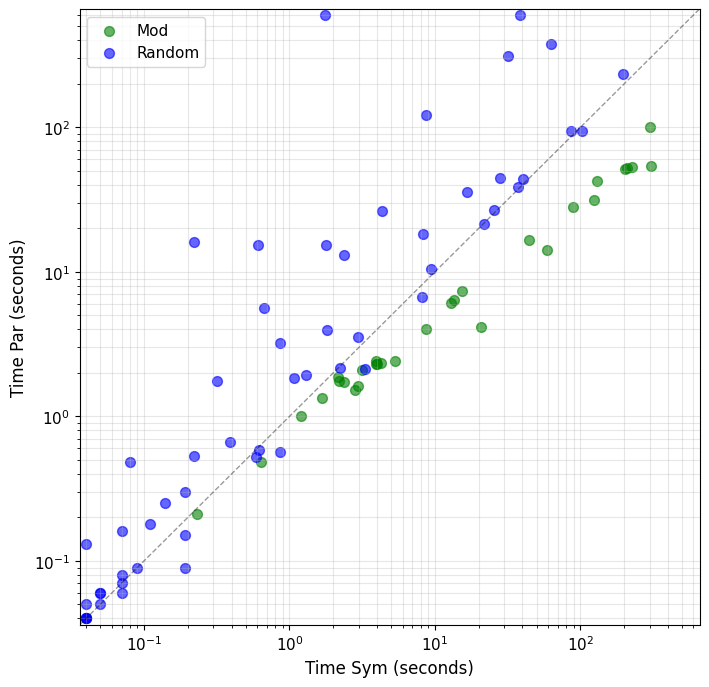

In [9]:
plot_scatter_solvers(
    table = table_2_20,
    solvers=['sym_2_20', 'par_2_20'],
    verdict_types=['sat', 'unsat', 'timeout'],
    labels={'sym_2_20': 'Sym', 'par_2_20': 'Par'},
    colors={'sym_2_20': 'blue', 'par_2_20': 'red'},  # ignored when using categories
    plot_name='scatter-2-20-existence.pgf',
    category_col='category',                         # column with categories
    category_colors={
        'modular': 'green',
        'divisibility': 'red',
        'random_e': 'blue'
    },
    category_labels={
        'modular': 'Mod',
        'divisibility': 'Div',
        'random_e': 'Random'
    }, 
    logscale = True
)

# Benchmark: Split 21-200 - Existence problem

In [17]:
# Category: Modular

par_21_200_modular =  pd.read_csv("CSV/modular/21-200/modular-21-par.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_modular =  pd.read_csv("CSV/modular/21-200/modular-21-sym.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

modular_21_200 = par_21_200_modular
modular_21_200 = sym_21_200_modular.join(modular_21_200.set_index("instance"), on="instance", how="left")
modular_21_200['category'] = "modular"

# Category: Random (Existence)

par_21_200_random_e =  pd.read_csv("CSV/random/21-200/random-21-par-e.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_random_e =  pd.read_csv("CSV/random/21-200/random-21-sym-e.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

random_21_200_e = par_21_200_random_e
random_21_200_e = sym_21_200_random_e.join(random_21_200_e.set_index("instance"), on="instance", how="left")
random_21_200_e['category'] = "random_e"

# Category: Mixed (Existence)

# par_21_200_mixed_e =  pd.read_csv("CSV/mixed/21-200/mixed-21-par-e.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
# sym_21_200_mixed_e =  pd.read_csv("CSV/mixed/21-200/mixed-21-sym-e.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

# mixed_21_200_e = par_21_200_mixed_e
# mixed_21_200_e = sym_21_200_mixed_e.join(mixed_21_200_e.set_index("instance"), on="instance", how="left")
# mixed_21_200_e['category'] = "random_e"

# Combine Tables 

table_21_200 = pd.concat([modular_21_200, 
                          random_21_200_e, 
                          # mixed_21_200_e
                         ], ignore_index=True)
table_21_200

,instance,verdict_sym_21_200,time_sym_21_200,verdict_par_21_200,time_par_21_200,category
0,ai-instances/random/random_09.smt2,sat,16.04,sat,15.31,random_e
1,ai-instances/random/random_03.smt2,sat,3.37,sat,3.10,random_e
2,ai-instances/random/random_01.smt2,unsat,0.37,unsat,0.41,random_e
3,ai-instances/random/random_19.smt2,unsat,251.5,unsat,289.14,random_e
4,ai-instances/random/random_15.smt2,sat,0.1,sat,0.05,random_e
5,ai-instances/random/random_14.smt2,sat,1.41,sat,0.71,random_e
6,ai-instances/random/random_02.smt2,sat,0.04,sat,0.05,random_e
7,ai-instances/random/random_20.smt2,sat,0.04,sat,0.05,random_e
8,ai-instances/random/random_13.smt2,sat,0.28,sat,0.55,random_e
9,ai-instances/random/random_07.smt2,sat,0.81,sat,0.24,random_e


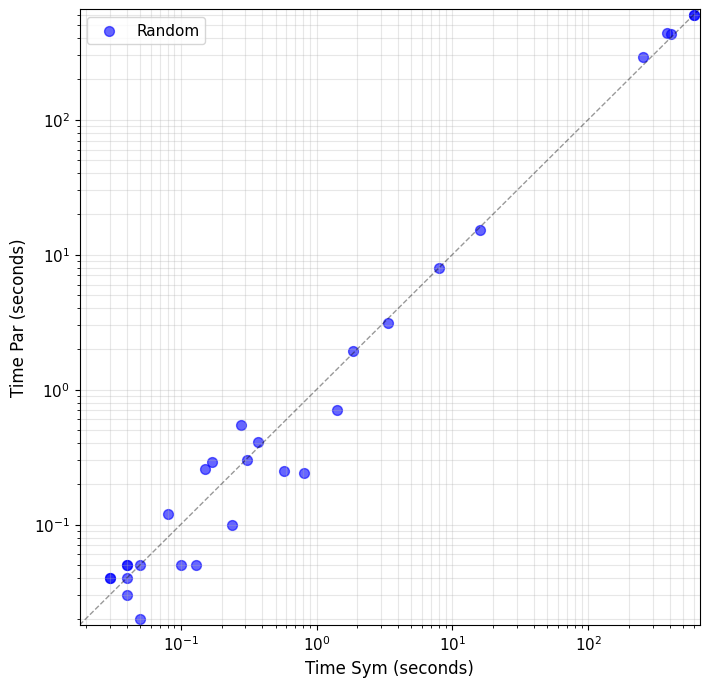

In [11]:
plot_scatter_solvers(
    table = table_21_200,
    solvers=['sym_21_200', 'par_21_200'],
    verdict_types=['sat', 'unsat', 'timeout'],
    labels={'sym_21_200': 'Sym', 'par_21_200': 'Par'},
    colors={'sym_21_200': 'blue', 'par_21_200': 'red'},  # ignored when using categories
    plot_name='scatter-21-200-existence.pgf',
    category_col='category',                         # column with categories
    category_colors={
        'modular': 'green',
        'divisibility': 'red',
        'random_e': 'blue'
    },
    category_labels={
        'modular': 'Mod',
        'divisibility': 'Div',
        'random_e': 'Random'
    }, 
    logscale = True
)

# Benchmark: Split 201-220 - Existence problem

### Instances

In [12]:
# Category: Modular

par_201_220_modular =  pd.read_csv("CSV/modular/201-220/modular-201-par.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_modular =  pd.read_csv("CSV/modular/201-220/modular-201-sym.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

modular_201_220 = par_201_220_modular
modular_201_220 = sym_201_220_modular.join(modular_201_220.set_index("instance"), on="instance", how="left")
modular_201_220['category'] = "modular"

# Category: Random (Existence)

par_201_220_random_e =  pd.read_csv("CSV/random/201-220/random-201-par-e.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_random_e =  pd.read_csv("CSV/random/201-220/random-201-sym-e.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

random_201_220_e = par_201_220_random_e
random_201_220_e = sym_201_220_random_e.join(random_201_220_e.set_index("instance"), on="instance", how="left")
random_201_220_e['category'] = "random_e"

# Category: Mixed (Existence)

par_201_220_mixed_e =  pd.read_csv("CSV/mixed/201-220/mixed-201-par-e.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_mixed_e =  pd.read_csv("CSV/mixed/201-220/mixed-201-sym-e.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

mixed_201_220_e = par_201_220_mixed_e
mixed_201_220_e = sym_201_220_mixed_e.join(mixed_201_220_e.set_index("instance"), on="instance", how="left")
mixed_201_220_e['category'] = "random_e"

# Combine Tables 

table_201_220 = pd.concat([modular_201_220, random_201_220_e, mixed_201_220_e], ignore_index=True)
table_201_220

,instance,verdict_sym_201_220,time_sym_201_220,verdict_par_201_220,time_par_201_220,category
0,ai-instances/modular/modular_23.smt2,unsat,2.55,unsat,1.80,modular
1,ai-instances/modular/modular_02.smt2,sat,0.77,sat,0.38,modular
2,ai-instances/modular/modular_17.smt2,unsat,170.29,unsat,70.29,modular
3,ai-instances/modular/modular_12.smt2,unsat,1.46,unsat,1.29,modular
4,ai-instances/modular/modular_05.smt2,sat,6.63,sat,4.80,modular
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_11.smt2,sat,0.26,sat,0.29,random_e
86,ai-instances/random-mixed/mixed_05.smt2,sat,5.16,sat,6.17,random_e
87,ai-instances/random-mixed/mixed_22.smt2,sat,0.35,sat,0.17,random_e
88,ai-instances/random-mixed/mixed_12.smt2,sat,0.19,sat,0.18,random_e


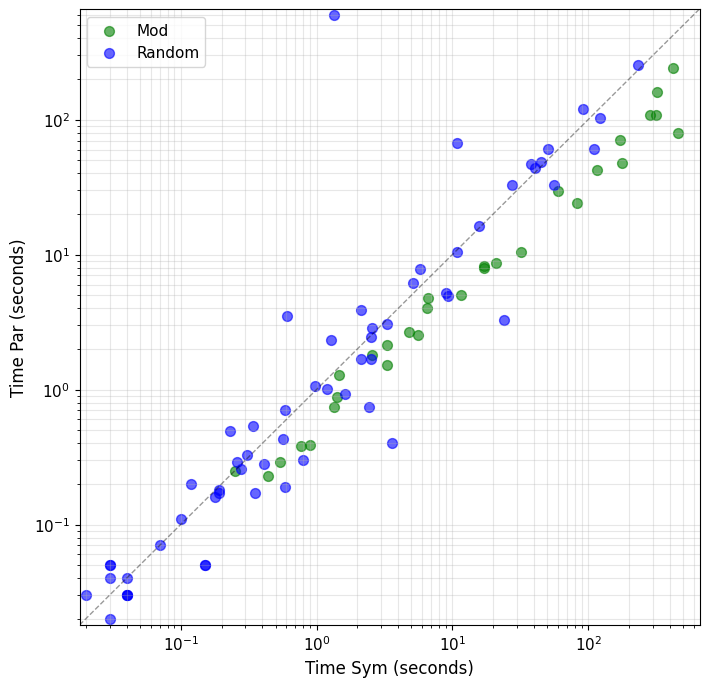

In [13]:
plot_scatter_solvers(
    table = table_201_220,
    solvers=['sym_201_220', 'par_201_220'],
    verdict_types=['sat', 'unsat', 'timeout'],
    labels={'sym_201_220': 'Sym', 'par_201_220': 'Par'},
    colors={'sym_201_220': 'blue', 'par_201_220': 'red'},  # ignored when using categories
    plot_name='scatter-201-220-existence.pgf',
    category_col='category',                         # column with categories
    category_colors={
        'modular': 'green',
        'divisibility': 'red',
        'random_e': 'blue'
    },
    category_labels={
        'modular': 'Mod',
        'divisibility': 'Div',
        'random_e': 'Random'
    }, 
    logscale = True
)